# Normalization and Convex Optimization Investigation

In this notebook, we will explore the non-negativity of f constraint and its affect on the optimal solution. Also we want to see if we can normalize in such a way that keeps the comparative analysis of cell cycling genes valid.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


(18.157057689732632, 938.3654839646116)

In [109]:
def custom_normalization(g):
    """
    Attempting a normalization scheme based on the min and max values of the gene.
    
    TODO: This is just a proof of concept as we work out the reasoning behind,
    the need to scale with this method and constant.
    """
    min_val, max_val = g.min(), g.max()
    diff = max_val-min_val
    translation = 4
    g = (g-min_val) / diff + translation

    return g

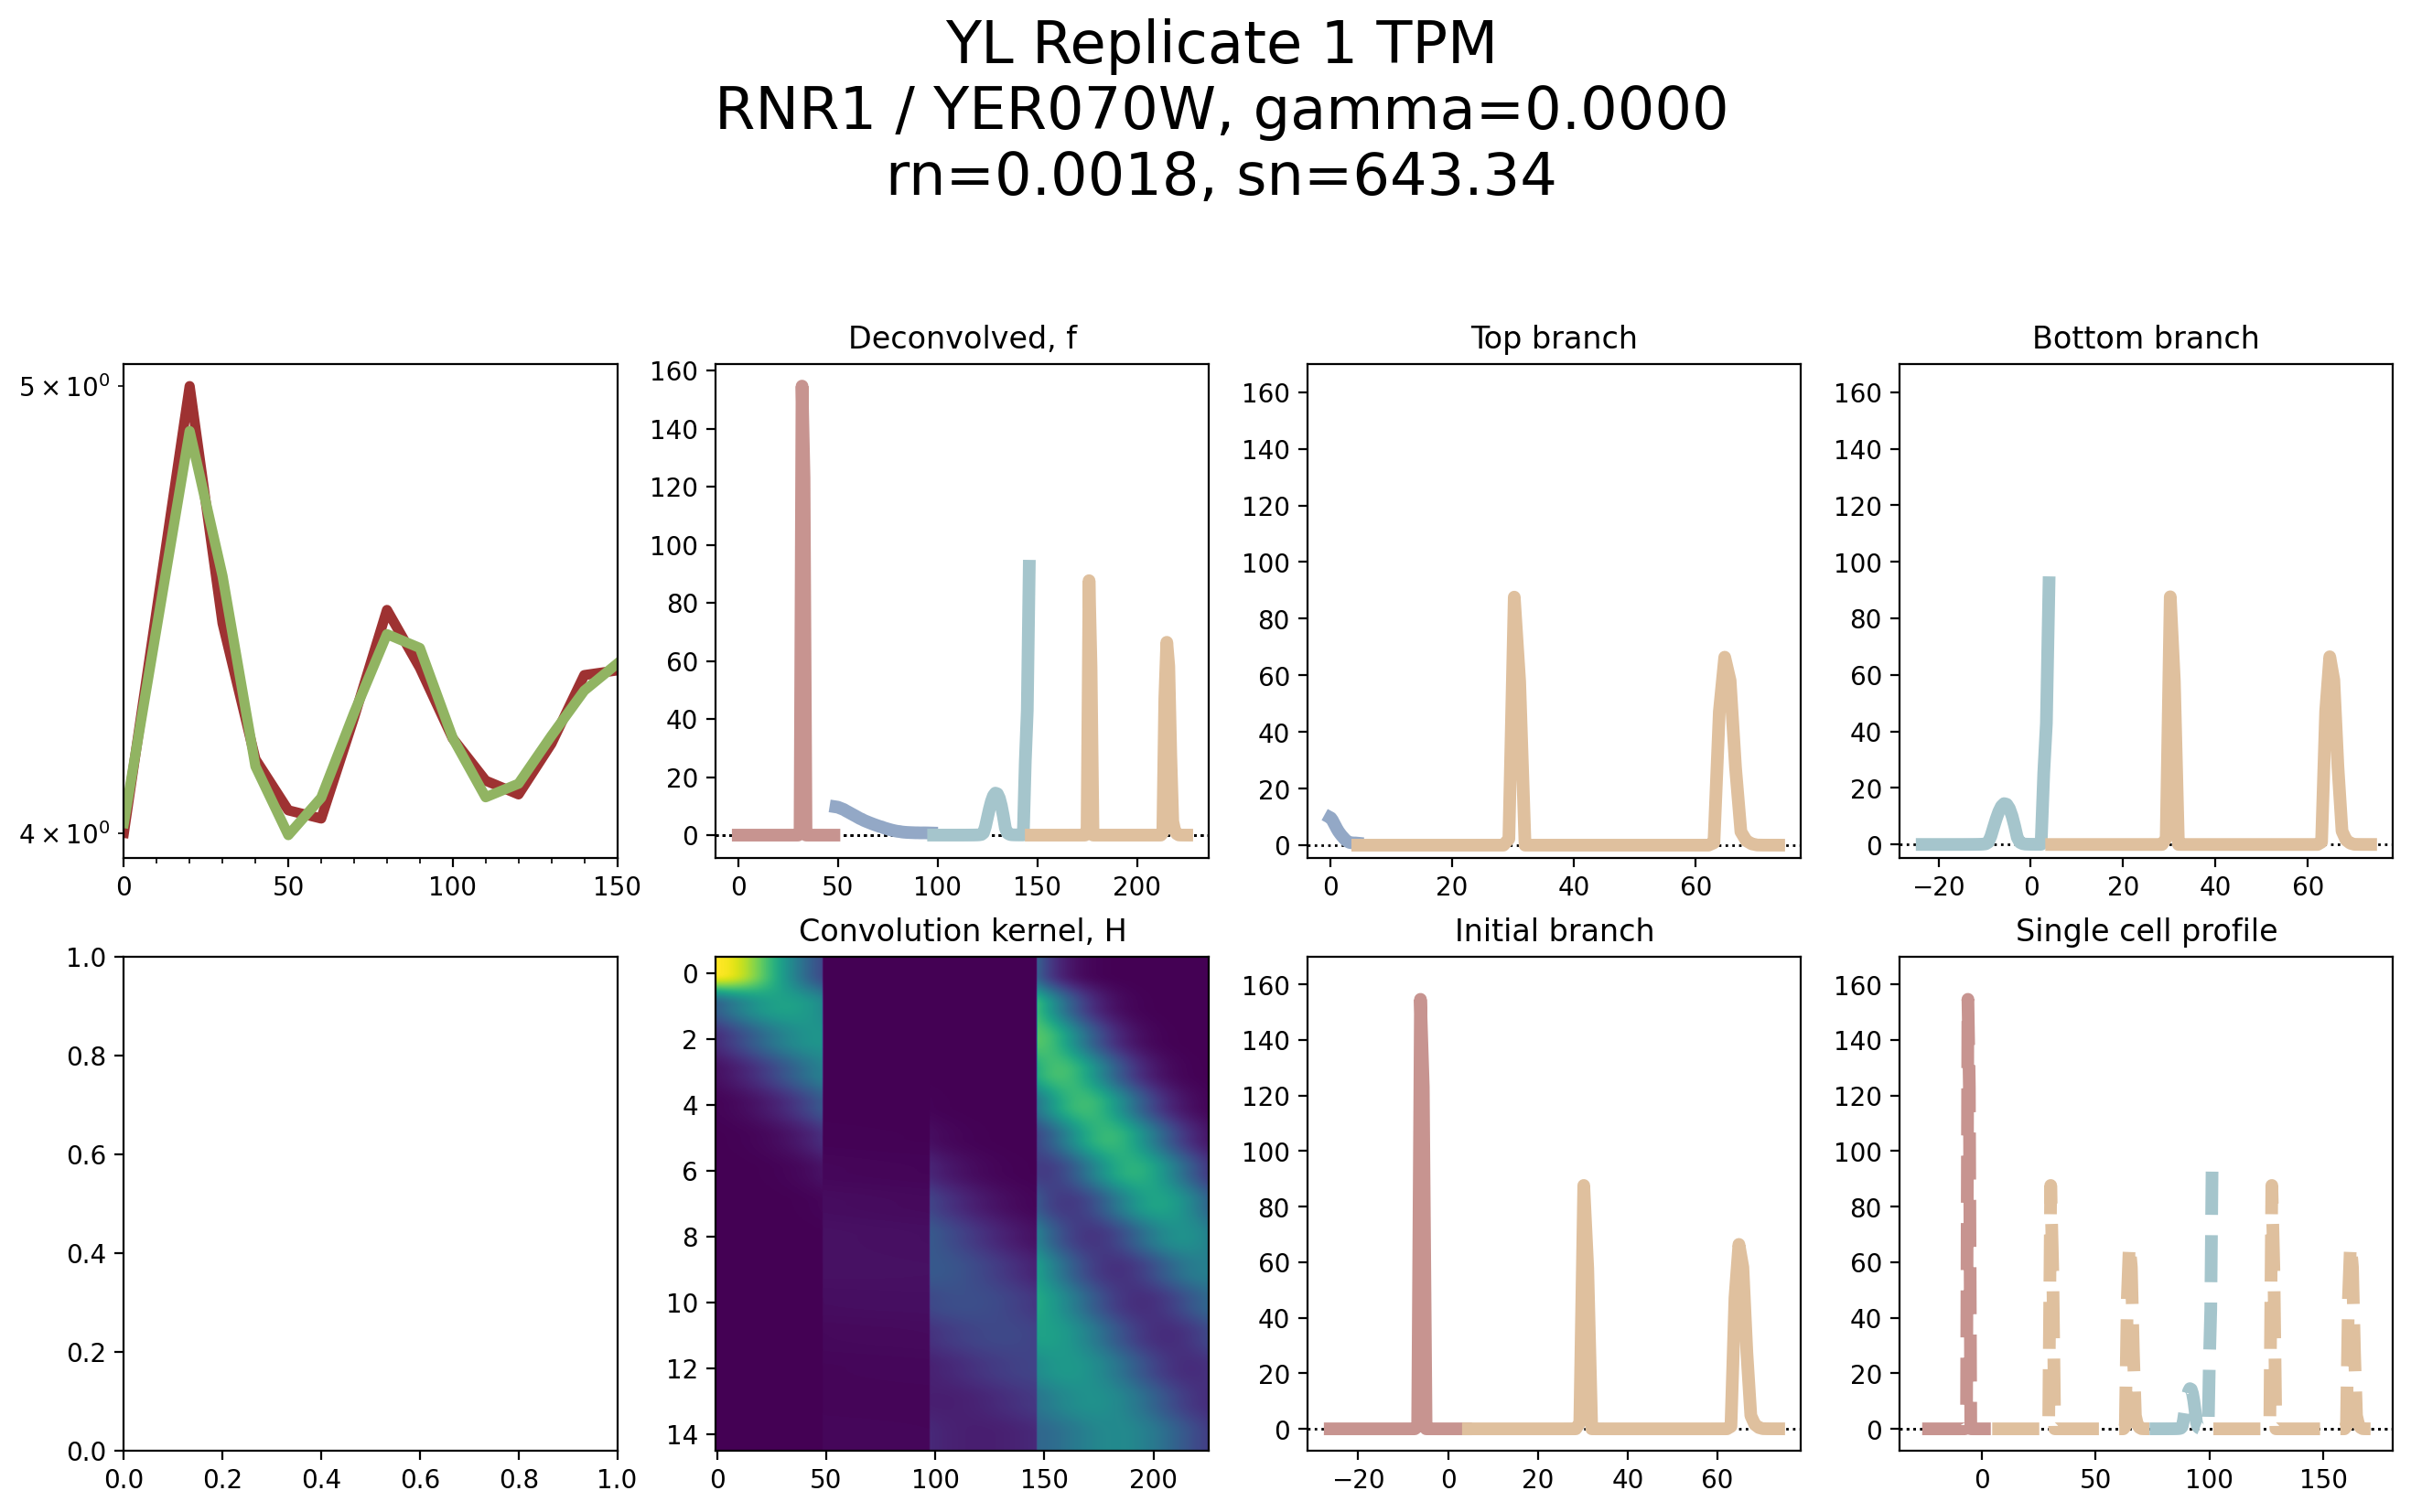

In [112]:
from src.config import load_yl_replicate1_rg1_TPM_config
from src.model import Model

tpm_config = load_yl_replicate1_rg1_TPM_config()
tpm_model = Model(config=tpm_config, gamma=0.0, gene_or_orfname='RNR1')
tpm_model.g = custom_normalization(tpm_model.g)
tpm_model.g1 = custom_normalization(tpm_model.g1)
tpm_model.deconvolve()
tpm_model.plot_deconvolved_gene()

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


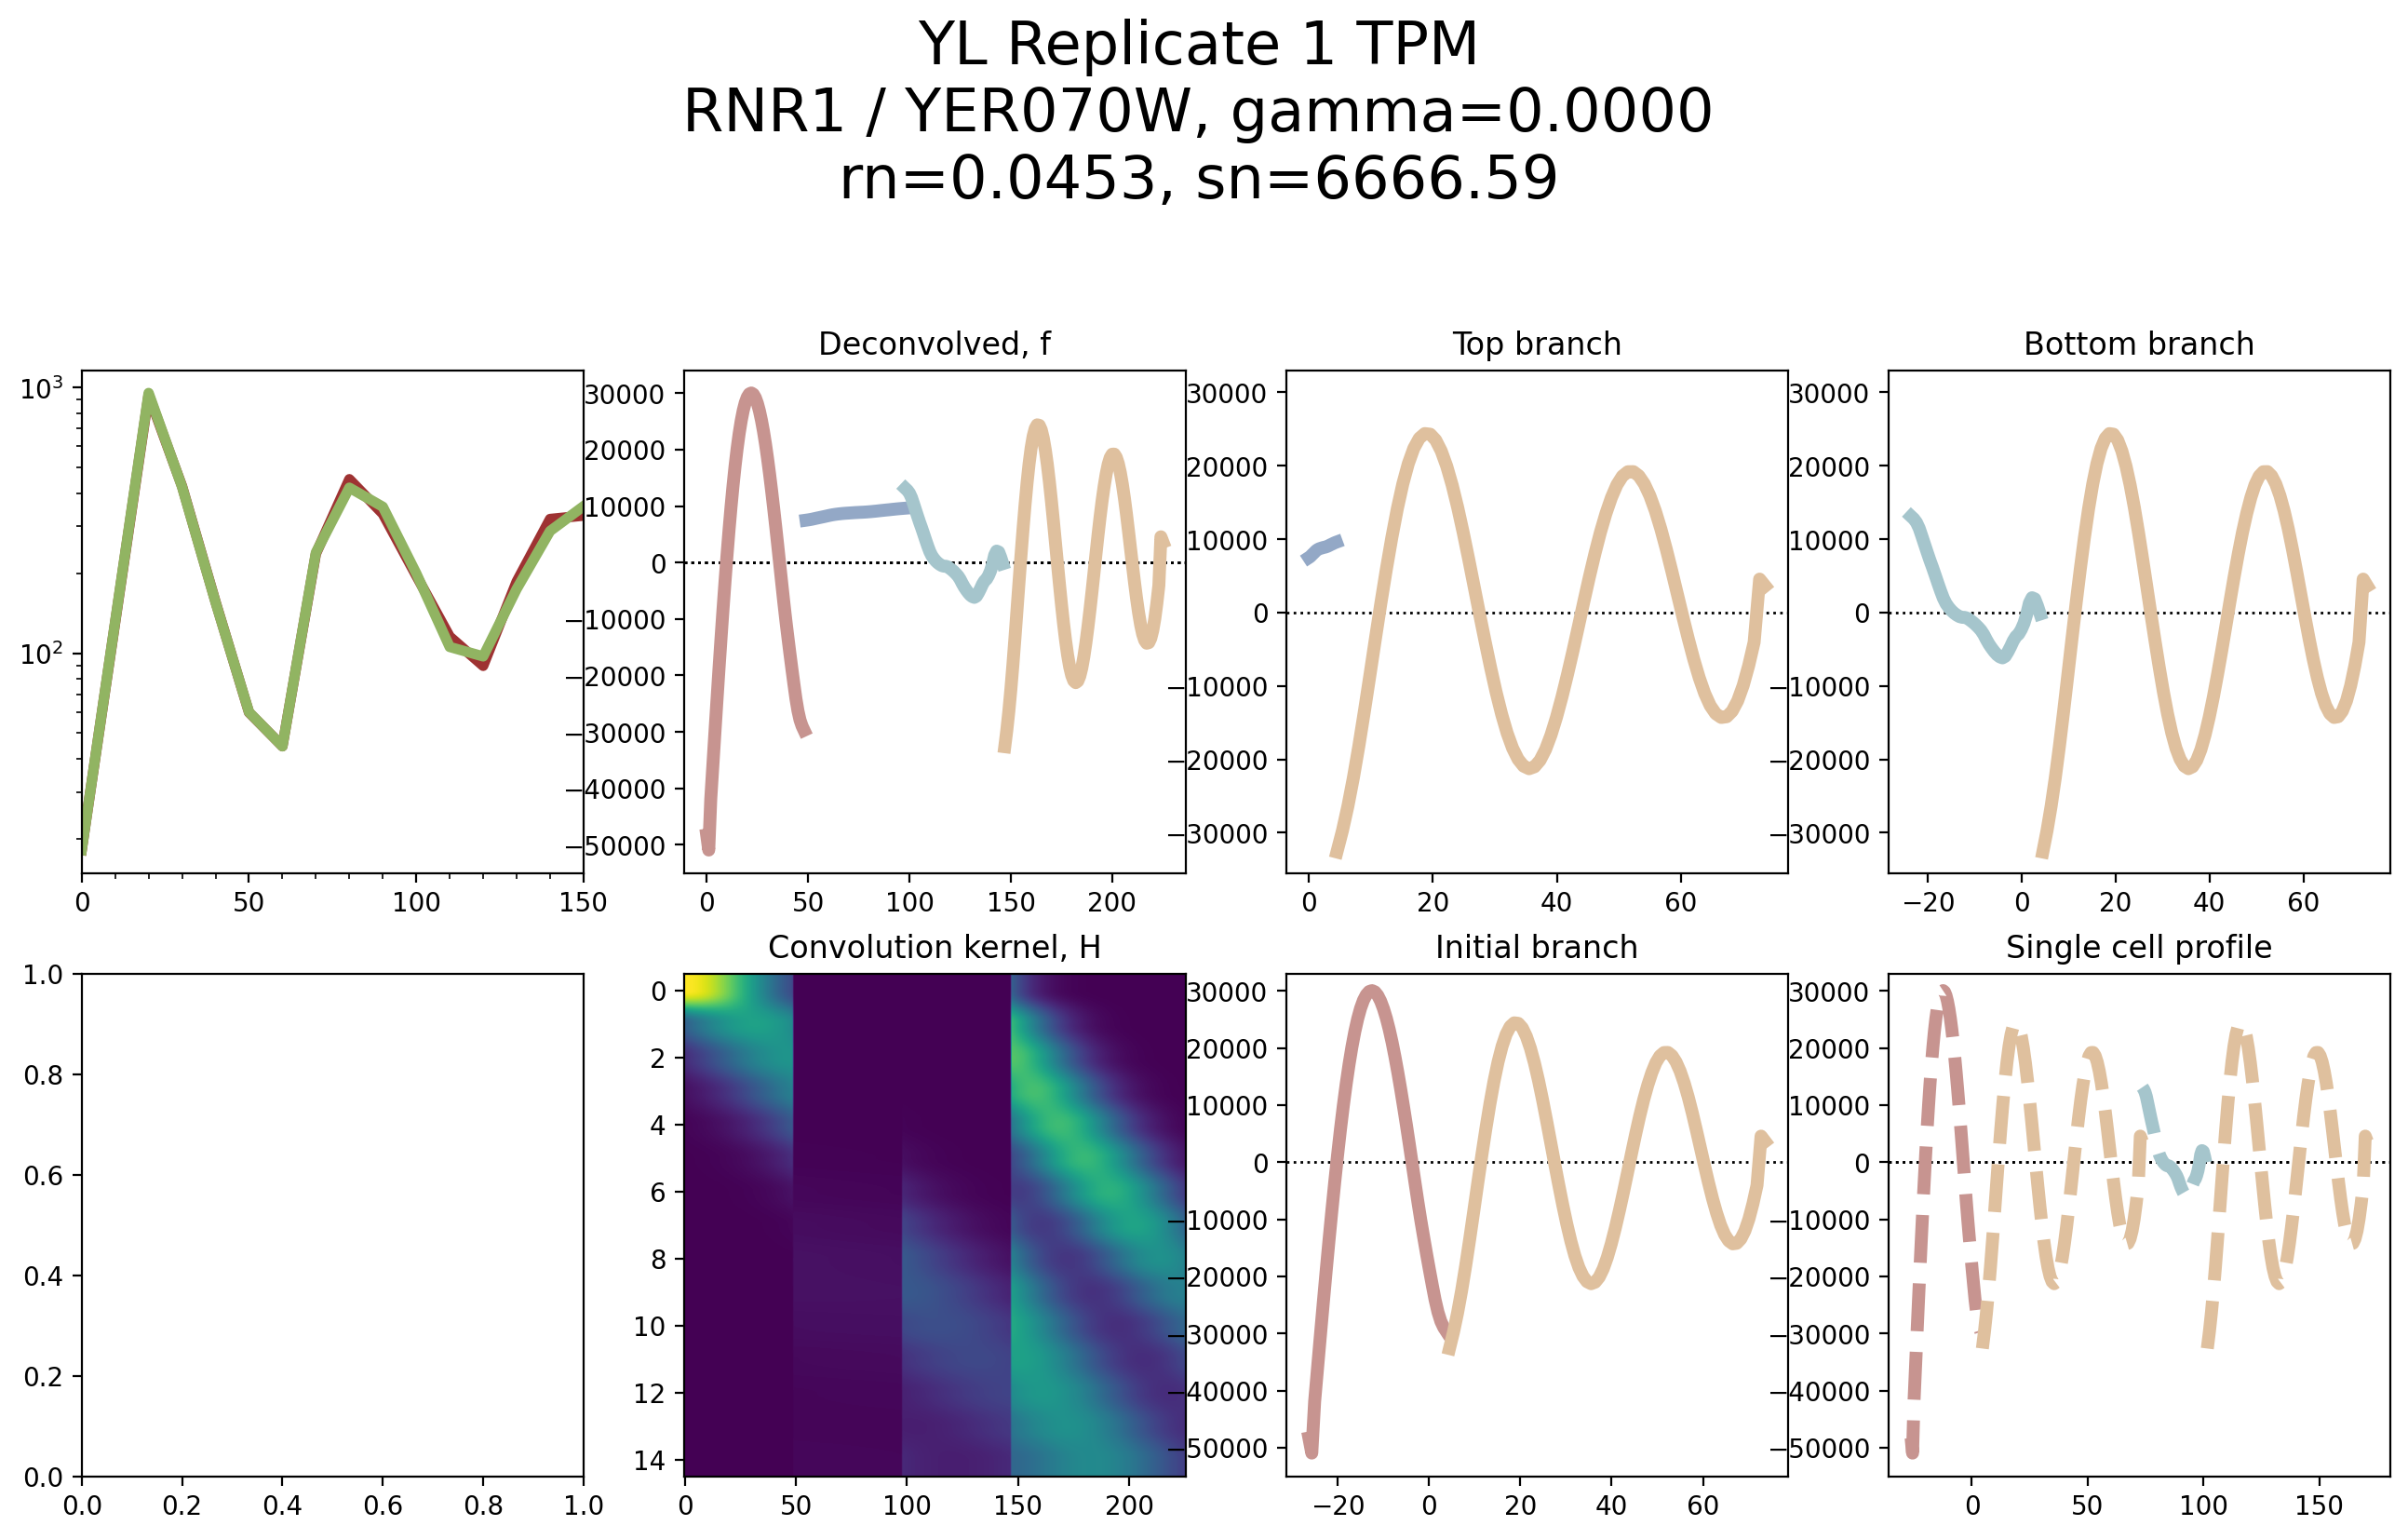

In [120]:
tpm_config = load_yl_replicate1_rg1_TPM_config()
tpm_model = Model(config=tpm_config, gamma=0.0, gene_or_orfname='RNR1')
#tpm_model.g = custom_normalization(tpm_model.g)
#tpm_model.g1 = custom_normalization(tpm_model.g1)
tpm_model.deconvolve(enforce_non_negative=False)
tpm_model.plot_deconvolved_gene()

In [127]:
meta_vals.max().maxs

20366.00061282172

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


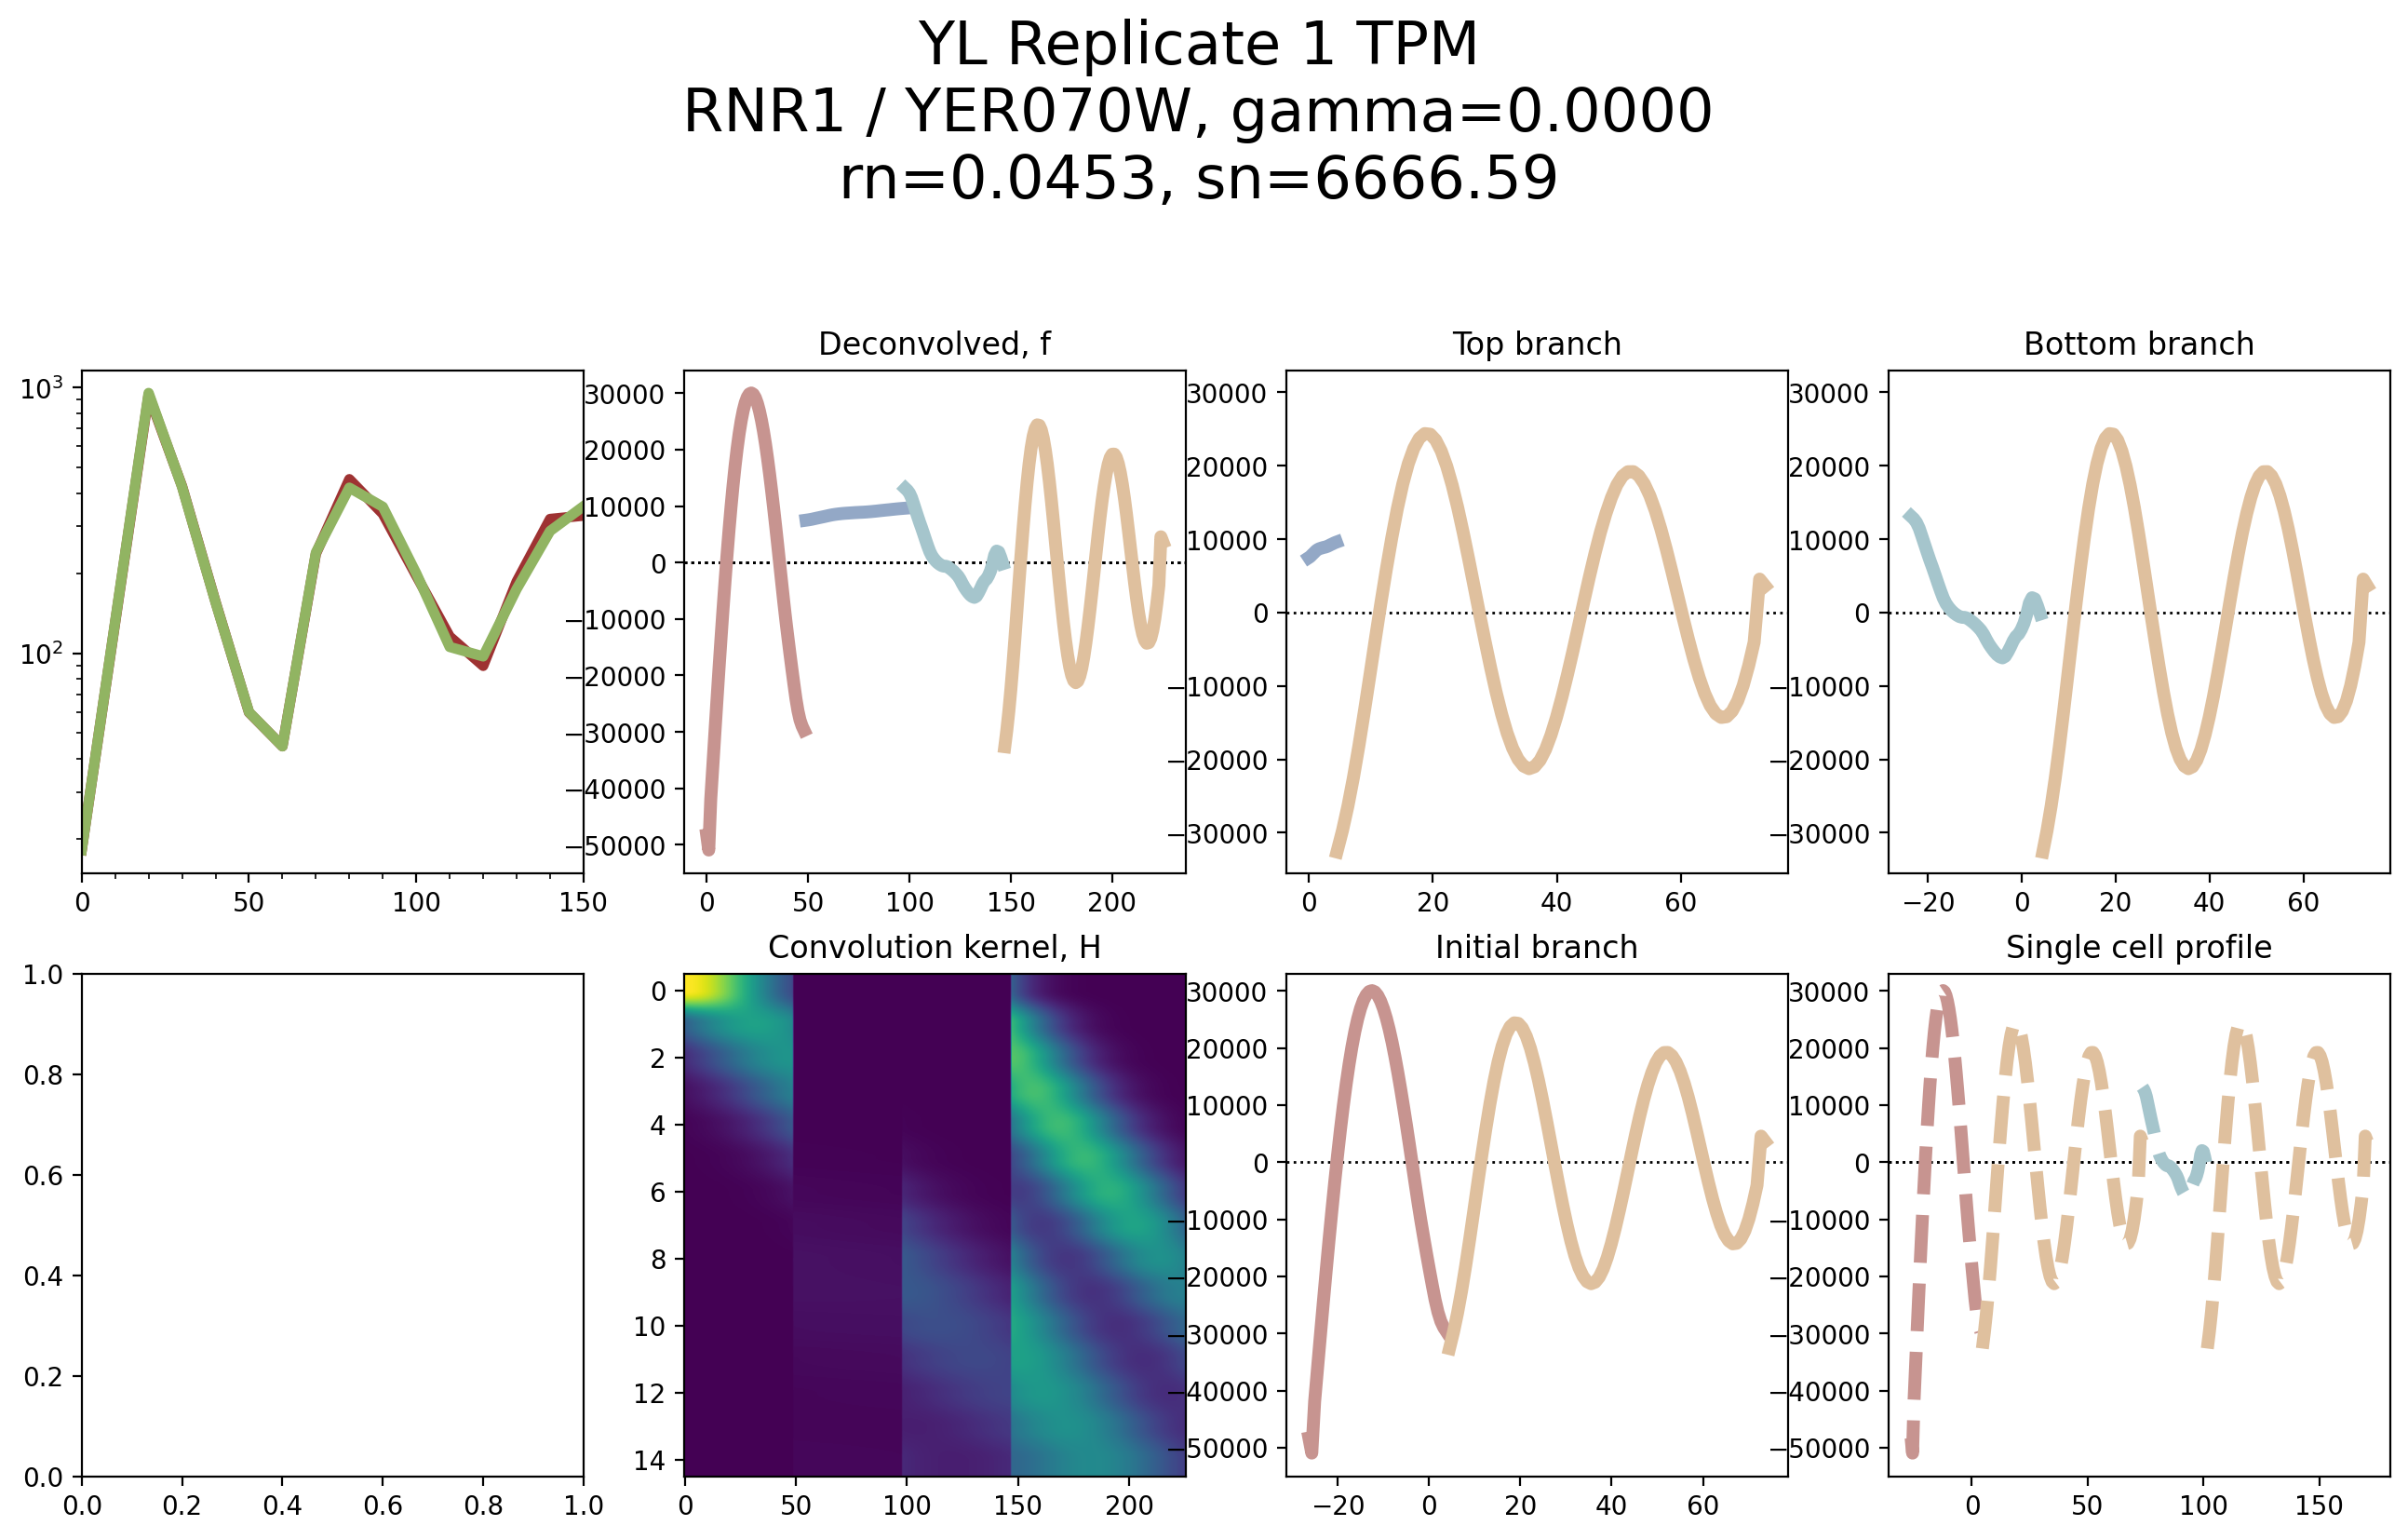

In [145]:
#norm_max_p1 = (tpm_config.wt1_df / meta_vals.max().maxs) + 10

tpm_config = load_yl_replicate1_rg1_TPM_config()
tpm_model = Model(config=tpm_config, gamma=0.0, gene_or_orfname='RNR1')

#tpm_model.g = norm_max_p1.loc[tpm_model.orf_name]
#tpm_model.g1 = norm_max_p1.loc[tpm_model.orf_name]

tpm_model.deconvolve(enforce_non_negative=False)
tpm_model.plot_deconvolved_gene()



In [144]:
#plt.plot(tpm_model.g)